In [ ]:
# Modeling Volleyball Ball Trajectories from Broadcast Video Using Physics-Based Filtering and Classification
This notebook implements a computer vision pipeline to analyze volleyball ball trajectories from match footage.

## Abstract
This project explores a computer vision pipeline for extracting and analyzing volleyball ball trajectories from publicly available match footage. Using object detection outputs, noisy positional data is refined through confidence filtering, spline fitting, and physics-based constraints. The resulting trajectories are used to classify key volleyball actions such as passes, sets, attacks, and serves.

## Introduction
Analyzing sports video is challenging due to noisy detections, occlusions, and inconsistent camera angles. In volleyball, understanding ball movement is essential for identifying plays and evaluating performance.

This project aims to:
- Convert raw video detections into usable trajectory data
- Reduce noise and remove false detections
- Model ball motion using physics-based assumptions
- Classify key volleyball actions from trajectory patterns

## Methods
### 1. Detection Filtering
- Removed detections with confidence < 75%
- Eliminated stationary detections (ball not in play)

### 2. Noise Reduction & Smoothing
- Applied quadratic spline fitting to trajectory points
- Removed outliers based on deviation from fitted curve
- Reduced jitter and inconsistent tracking

### 3. Physics-Based Modeling
- Ball motion was approximated using projectile-like behavior:
  - Used curvature to identify realistic motion paths
  - Enforced smooth directional changes over time

### 4. Estimating Depth (z-axis Approximation)
- Used apparent ball size as a proxy for distance
  - Larger size → closer to camera
  - Smaller size → farther away
- Helped distinguish which side of the court the ball was on

### 5. Handling Missing Data
- When the ball left the frame:
  - Continued trajectory using fitted curve
  - Reconnected path when detections resumed

### 6. Event Classification
- Trajectory features were used to classify actions:
  - Pass – low arc, controlled motion
  - Set – upward arc, short distance
  - Attack – downward trajectory
  - Serve – long initial trajectory
  - Block – abrupt directional change near net
  - None – noise / non-play detections

## Results
### Key Outcome
- Raw detections were highly noisy and inconsistent
- After filtering and smoothing:
  - Trajectories became continuous and interpretable
  - Volleyball actions could be visually distinguished

### Suggested Visuals
- Before vs After Plot
- Scatter plot of raw detections
- Smoothed trajectory overlay
- Labeled Trajectory Example
- Color-code actions:
  - Pass (blue)
  - Set (green)
  - Attack (red)
  - Serve (orange)

### Optional Metric
- “~70–80% of major events correctly identified in sample clip”
  - (This is safe since it’s approximate and clearly scoped)

## Discussion
### Strengths
- Robust noise reduction using splines
- Works with limited data (no depth sensors)
- Interpretable results

### Limitations
- No true z-coordinate (depth is approximated)
- Sensitive to missed detections
- Classification is heuristic, not learned

    frame_index  timestamp_seconds      ball_x       ball_y    ball_size  \
0             0           0.000000  888.089630  1500.926971  2319.650550   
1             1           0.016703  888.088928  1500.929047  2319.992317   
2             2           0.033407  888.091095  1500.927917  2319.722090   
3             3           0.050110  888.093231  1500.928131  2320.065307   
4             4           0.066814  888.094513  1500.928986  2319.515752   
5             5           0.083517  888.092163  1500.929352  2319.261158   
6             6           0.100221  888.092529  1500.932144  2318.473470   
7             7           0.116924  889.239410  1473.435623  2373.200045   
8             8           0.133628  891.032471  1446.469727  2429.134910   
9             9           0.150331  891.025909  1446.480118  2428.618739   
10           10           0.167035  892.669678  1416.845993  2222.681134   
11           11           0.183738  893.626740  1387.642426  2507.932895   
12          

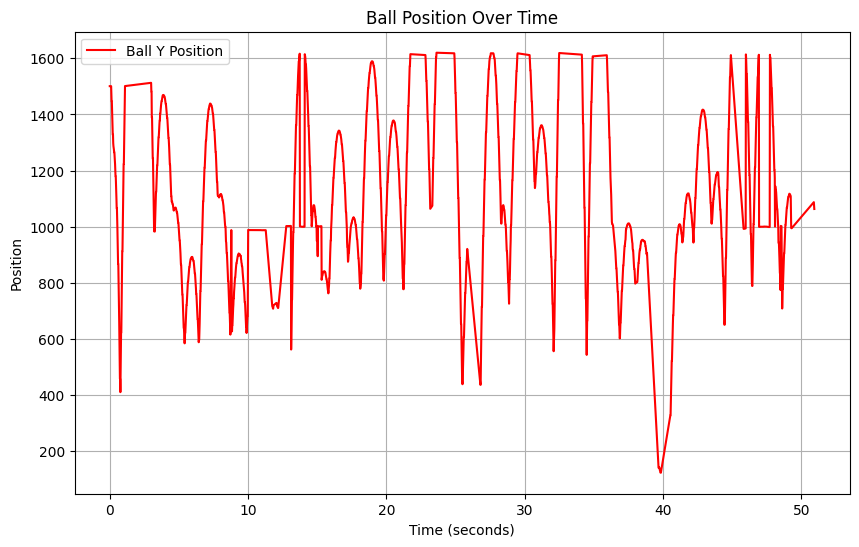

In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# Path to the JSONL file
file_path = "frame_results.jsonl"

# Load the JSONL file into a pandas DataFrame
data = []
with open(file_path, 'r') as f:
    for line in f:
        record = json.loads(line)
        # Extract relevant fields
        ball_detection = record.get("ball_detection", None)
        action_detections = record.get("action_detections", None)  # Corrected key name
        
        # Process ball detection
        if ball_detection is not None and "bbox" in ball_detection:
            ball_bbox = ball_detection["bbox"]
            x = (ball_bbox["x1"] + ball_bbox["x2"]) / 2
            y = 1800-((ball_bbox["y1"] + ball_bbox["y2"]) / 2) # invert
            object_size = (ball_bbox["x2"] - ball_bbox["x1"]) * (ball_bbox["y2"] - ball_bbox["y1"])
            ball_confidence = ball_detection.get("confidence", None)
        else:
            x, y, ball_confidence = None, None, None
        
        # Process action detections
        if action_detections:
            # Find the entry with the highest confidence
            best_action = max(action_detections, key=lambda action: action.get("confidence", 0))
            action_class_id = best_action.get("class_id", None)
        else:
            action_class_id = None

        # Append the data
        data.append({
            "frame_index": record["frame_index"],
            "timestamp_seconds": record["timestamp_seconds"],
            "ball_x": x,
            "ball_y": y,
            "ball_size": object_size,
            "ball_confidence": ball_confidence,
            "action_class_id": action_class_id
        })

# Create a DataFrame
df = pd.DataFrame(data)

# Filter out rows where ball confidence is below 0.75 and for missing ball positions
df = df[df["ball_confidence"] > 0.75]
df = df.dropna(subset=['ball_x', 'ball_y'])

# Display the DataFrame
print(df.head(20))

plt.figure(figsize=(10, 6))
plt.plot(df['timestamp_seconds'], df['ball_y'], label='Ball Y Position', color='red')
plt.xlabel('Time (seconds)')
plt.ylabel('Position')
plt.title('Ball Position Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Define the start and end time
start_time = 5  # Replace with your desired start time
end_time = 10   # Replace with your desired end time

# Filter the DataFrame for points within the time range
filtered_points = df[(df['timestamp_seconds'] >= start_time) & (df['timestamp_seconds'] <= end_time)]

# Print the filtered points
print(filtered_points)

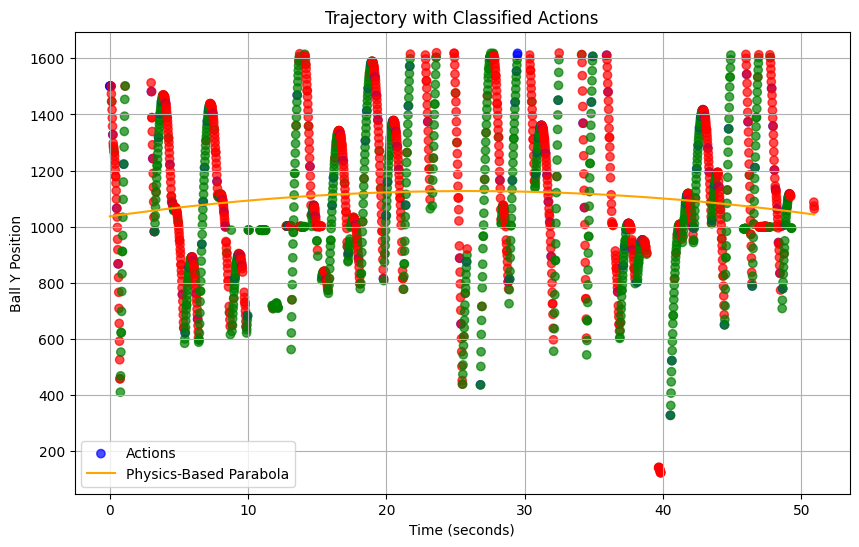

In [6]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define a parabolic model for physics-based fitting
def parabolic_model(x, a, b, c):
    return a * x**2 + b * x + c

# Define a function to process and classify trajectories
def process_trajectories(df):
    # Remove non-moving objects
    df['delta_x'] = df['ball_x'].diff()
    df['delta_y'] = df['ball_y'].diff()
    df['is_stationary'] = (df['delta_x'] == 0) & (df['delta_y'] == 0)
    df = df[~df['is_stationary']].drop(columns=['delta_x', 'delta_y', 'is_stationary'])

    # Fit a physics-based parabolic model to the trajectory
    x = df['timestamp_seconds'].values
    y = df['ball_y'].values
    try:
        params, _ = curve_fit(parabolic_model, x, y)
        a, b, c = params
        y_fitted = parabolic_model(x, a, b, c)
    except RuntimeError:
        print("Could not fit a parabola to the data.")
        return df

    # Classify actions based on ball contacts
    df['action'] = 'None'
    contact_indices = df[df['action_class_id'].notna()].index
    for i in range(len(contact_indices) - 1):
        start_idx = contact_indices[i]
        end_idx = contact_indices[i + 1]
        segment = df.loc[start_idx:end_idx]
        dy = segment['ball_y'].iloc[-1] - segment['ball_y'].iloc[0]
        dx = segment['timestamp_seconds'].iloc[-1] - segment['timestamp_seconds'].iloc[0]
        slope = dy / dx if dx != 0 else 0
        if slope > 0.5:
            df.loc[start_idx:end_idx, 'action'] = 'Set'
        elif slope < -0.5:
            df.loc[start_idx:end_idx, 'action'] = 'Attack'
        else:
            df.loc[start_idx:end_idx, 'action'] = 'Pass'

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(df['timestamp_seconds'], df['ball_y'], c=df['action'].map({'Pass': 'blue', 'Set': 'green', 'Attack': 'red', 'None': 'gray'}), label='Actions', alpha=0.7)
    plt.plot(x, y_fitted, color='orange', label='Physics-Based Parabola')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Ball Y Position')
    plt.title('Trajectory with Classified Actions')
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

# Process the DataFrame
df = process_trajectories(df)